In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

In [2]:
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler
import cup_common as cc
import nn_common as nnc
import cross_common as cr
import torch
import importlib
from functools import partial
import copy
from nn_common import FeatureTargetSet, HoldOutStrategy, EarlyStoppingStrategy
from cross_common import EPOCHS_VL_LOSS,FOLD_VL_LOSS,FOLD_TR_LOSS
from cross_common import MEE,MSE,RMSE,MAE,LOSS


importlib.reload(nnc)
importlib.reload(cc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

In [3]:
# Controls neural-network weight initialization, mini-batch ordering,
# and all stochastic operations performed during model training.
#TRAINING_SEED = 1
#TRAINING_SEED = 10
TRAINING_SEED = 20

# Controls the sequence of hyperparameter configurations suggested by
# Optuna, making the optimization procedure reproducible across runs.
OPTUNA_SEED = cr.SEED

# Controls the shuffled K-Fold partitioning, ensuring that every model
# configuration is evaluated using the same cross-validation folds.
CV_RANDOM_STATE = cr.RANDOM_STATE #42

nnc.set_global_seed(TRAINING_SEED)

def optuna_tpe_sampler(seed:int):
    """
    Create a reproducible Optuna TPE sampler.
    A new sampler instance must be created for each independent study.
    :param seed: the random seed
    :return: a sampler object
    """
    return optuna.samplers.TPESampler(seed=seed)


def optuna_grid_sampler(search_space: dict, seed: int):
    """Create a reproducible Optuna grid sampler.
    A new sampler instance must be created for each independent study.
    :param search_space: the search space
    :param seed: the random seed
    :return: a sampler object
    """
    return optuna.samplers.GridSampler(search_space,seed=seed)


<h1>NN - Optuna</h1>
<h2>Exploring the cup dataset with NN Classifier with the help of Optuna tools.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [4]:
importlib.reload(cr)
df_train, df_test = cc.load_set()

# Scaler
scaler = StandardScaler()

# The train set used for model selection
X_ts, y_ts = cc.prepare_dataset(df_test)

# Split the 500 labelled samples:
# - 80% development set for model selection and cross-validation
# - 20% internal test set for the final independent assessment
(
    X_tr, y_tr, # The train set
    X_internal_ts, y_internal_ts # The internal test set
 ) = (
    # by default 'prepare for hold out' split into 80% - 20%
    cc.prepare_dataset_for_hold_out(df_train,random_state=cc.INTERNAL_TEST_RANDOM_STATE)
)

features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,400,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [5]:

default_batch_size = [64]
default_epochs = 0

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 4

# fold strategy
base_fold_strategy = cr.common_fold_strategy(n_split=3, random_state=CV_RANDOM_STATE)


# ---- The metrics to calculate in train ---
epochs_metrics_dict = {
    MSE: (cr.mse,min),
    MAE: (cr.mae,min)
}
the_metrics = epochs_metrics_dict.keys()
# ------------------------------------------


# ----- Defining model basic architecture --------
base_hidden_layers = ["32"]

# The output and loss function, must be changed according to the type of task
loss_function = nnc.MEELoss()
# activation function
base_activation_function = ["relu"]
output_adapter = nnc.regression_adapter()
# ------------------------------------------


# ----- Learning rate and weight decay -----
base_weight_decay = [0]
base_learning_rates = [1e-4]
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by which learning rate will decrease
learning_rate_decay_factor = 0.5    #0.6 #0.5
# The epoch to wait before applying the rate decay factor (must be lower than early stopping)
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", threshold_mode = "abs", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------

# Base trial dictionary to progressively update
base_trial_dict={
    "epochs": default_epochs,
    "batch_size": default_batch_size,
    "fold_strategy": base_fold_strategy,
    "input_dimension":input_dimension,
    "output_dimension":output_dimension,
    "hidden_layers": base_hidden_layers,
    "learning_rate": base_learning_rates,
    "weight_decay": base_weight_decay,
    "activation": base_activation_function,
    "output_adapter": output_adapter,
    "metrics": epochs_metrics_dict,
    "scheduler_template": scheduler_template,
    "seed": TRAINING_SEED
}

In [6]:
def objective(trial, X, y, trial_dict, objective_function):
    """
    Main objective function to be used with Optuna search.
    :param trial: the optuna trial object
    :param X: the feature
    :param y: the target
    :param trial_dict: the configuration dictionary
    :param objective_function: the objective function
    :return:
    """

    # PyTorch initialization and mini-batch ordering may vary between trials.
    # To compare hyperparameter configurations fairly, all random generators
    # are reset to the same seed at the beginning of each objective evaluation.
    nnc.set_global_seed(trial_dict["seed"])

    epochs_trial = trial_dict["epochs"]
    batch_size_trial = nnc.suggest_trial_param(trial, "batch_size", trial_dict["batch_size"])
    fold_strategy_trial = trial_dict["fold_strategy"]
    output_adapter_trial = trial_dict["output_adapter"]
    scheduler_template_trial = trial_dict.get("scheduler_template",None)
    hidden_layers_raw = nnc.suggest_trial_param(trial, "hidden_layers", trial_dict["hidden_layers"])
    hidden_layers_trial = [int(x) for x in hidden_layers_raw.split(",")]
    activation_trial = nnc.suggest_trial_param(trial,"activation", trial_dict["activation"])
    learning_rate_trial = nnc.suggest_trial_param(trial, "learning_rate", trial_dict["learning_rate"])
    weight_decay_trial = nnc.suggest_trial_param(trial, "weight_decay", trial_dict["weight_decay"])
    metrics_trial = trial_dict["metrics"]
    net_trial = nnc.build_nn_net(input_dimension, output_dimension, list(hidden_layers_trial), activation_trial)
    model_trial = nnc.build_nn_model(net_trial, output_adapter_trial)

    optimizer_template_trial = partial(
        torch.optim.AdamW,
        lr=learning_rate_trial,
        weight_decay=weight_decay_trial,
        betas=(0.95, 0.999)
    )

    inner_train_params_trial = {
        "epochs": epochs_trial,
        "batch_size": batch_size_trial,
        "scheduler_template": scheduler_template_trial,
        "optimizer_template": optimizer_template_trial,
        "loss_function": loss_function,
        "early_stopping_strategy": early_stopping_strategy,
        "silence_output": True,
        "additional_metrics": metrics_trial
    }

    return objective_function(
        nnc.kfold(model_trial, X, y, fold_strategy_trial, inner_train_params_trial, scaler)
    )


<h3>Optuna</h3>

<h4>Learning Rate</h4>
<hr>

<h5>Preparation</h5>

In [7]:

# partially instantiate evaluation funtion
evaluate_lr_partial = partial(
    nnc.evaluate_lr,
    epoch_metric=EPOCHS_VL_LOSS,
    fold_metric=FOLD_VL_LOSS,
    early_epoch=30
)
coarse_lr_space = [
    1e-4, 5e-4,
    1e-3, 2e-3,
    3e-3, 5e-3,
    8e-3, 1e-2,
    1.5e-2, 2e-2,
    3e-2, 5e-2,
    8e-2, 1e-1,
]

<h5>Coarse Grained</h5>

In [8]:
# as we are testing few lr a small
# nr of trials is enough
coarse_grained_trials_nr = len(coarse_lr_space)

base_trial_dict["learning_rate"] = coarse_lr_space
base_trial_dict["epochs"] = 100
# Temporarily disabling the lr scheduler
base_trial_dict["scheduler_template"] = None

objective_coarse_grained_lr_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_lr_partial,
    trial_dict=base_trial_dict
)

coarse_search_space = {
    "batch_size": base_trial_dict["batch_size"],
    "hidden_layers": base_trial_dict["hidden_layers"],
    "activation": base_trial_dict["activation"],
    "learning_rate": coarse_lr_space,
    "weight_decay": base_trial_dict["weight_decay"],
}

coarse_grained_lr_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize", "maximize"],
    sampler=optuna_grid_sampler(coarse_search_space, OPTUNA_SEED) # <- the sampler guarantees to try all the possibilities
)

coarse_grained_lr_study.optimize(objective_coarse_grained_lr_partial, show_progress_bar=True, n_trials=coarse_grained_trials_nr)

[I 2026-08-19 11:08:36,312] A new study created in memory with name: no-name-f4ff0014-144f-4f1f-acef-a0c5d47af6e5
  7%|▋         | 1/14 [00:02<00:36,  2.83s/it]

[I 2026-08-19 11:08:39,161] Trial 0 finished with values: [24.604510544865494, 0.00012019722180750373, 0.23883767291350502] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.002, 'weight_decay': 0}.


 14%|█▍        | 2/14 [00:04<00:26,  2.24s/it]

[I 2026-08-19 11:08:40,985] Trial 1 finished with values: [23.572873712402043, 0.001015684764596718, 0.18459697527991145] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.01, 'weight_decay': 0}.


 21%|██▏       | 3/14 [00:06<00:22,  2.03s/it]

...

[I 2026-08-19 11:08:59,587] Trial 11 finished with values: [23.354230093910513, 0.0018828596960823174, 0.14830045866932182] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.015, 'weight_decay': 0}.


 93%|█████████▎| 13/14 [00:25<00:01,  1.82s/it]

[I 2026-08-19 11:09:01,340] Trial 12 finished with values: [22.288179467718184, 0.007238822933089813, 0.09699670656024034] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.05, 'weight_decay': 0}.


100%|██████████| 14/14 [00:26<00:00,  1.91s/it]

[I 2026-08-19 11:09:03,119] Trial 13 finished with values: [23.865014461619648, 0.0003764212226423924, 0.22126175573946752] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.005, 'weight_decay': 0}.


In [9]:
coarse_grained_lr = nnc.find_best_lr_from_trials(coarse_grained_lr_study)
print(f"lr: {coarse_grained_lr}")

lr: 0.1


<h5>Fine Grained</h5>

In [10]:
# the number of trials depends on the
# suggestion returned by optuna
fine_grained_trials_nr=30

# Build a fine-grained search range around the best coarse learning rate
# by scaling it with a constant factor (lr / factor, lr * factor).
# This refines the search locally on a logarithmic scale.
# if coarse lr = 0.001 --> interval = (0.00033 , 0.003)
# (optuna will return --> [0.00033, 0.00045,0.00060,0.00080,0.00105,0.00140,0.00190,0.00250,0.003] )
constant_lr_factor = 3
low_lr = coarse_grained_lr / constant_lr_factor
high_lr = coarse_grained_lr * constant_lr_factor

base_trial_dict["learning_rate"] = (low_lr, high_lr)
base_trial_dict["epochs"] = 100

objective_fine_grained_lr_partial = partial(
    objective, X=X_tr, y=y_tr, objective_function = evaluate_lr_partial,
    trial_dict=base_trial_dict
)

fine_grained_lr_study = optuna.create_study(
    # same reason for "directions"
    directions=["minimize", "minimize", "maximize"],
    sampler=optuna_tpe_sampler(OPTUNA_SEED)
)
fine_grained_lr_study.optimize(objective_fine_grained_lr_partial, show_progress_bar=True, n_trials=fine_grained_trials_nr)

[I 2026-08-19 11:09:03,218] A new study created in memory with name: no-name-90836b53-d259-4a1e-9f13-ae8262faf13b
  3%|▎         | 1/30 [00:01<00:51,  1.76s/it]

[I 2026-08-19 11:09:04,979] Trial 0 finished with values: [22.23436369567912, 0.010655726577764176, 0.10958580236219818] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.08333335551236637, 'weight_decay': 0}.


  7%|▋         | 2/30 [00:03<00:48,  1.75s/it]

[I 2026-08-19 11:09:06,720] Trial 1 finished with values: [21.978608296543857, 0.016252468099472433, 0.09897814145145539] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.16227177904341394, 'weight_decay': 0}.


 10%|█         | 3/30 [00:05<00:47,  1.75s/it]

...

[I 2026-08-19 11:09:53,355] Trial 27 finished with values: [22.19475066863839, 0.006845753975717639, 0.09522396679829838] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.05082755401131175, 'weight_decay': 0}.


 97%|█████████▋| 29/30 [00:51<00:01,  1.77s/it]

[I 2026-08-19 11:09:55,109] Trial 28 finished with values: [22.021366277492145, 0.019115504688011754, 0.13889598935339287] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.23735681848408477, 'weight_decay': 0}.


100%|██████████| 30/30 [00:53<00:00,  1.79s/it]

[I 2026-08-19 11:09:56,967] Trial 29 finished with values: [22.121147776490147, 0.014291810158847229, 0.10961201194469135] and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.17034625485966517, 'weight_decay': 0}.


In [11]:
final_lr = nnc.find_best_lr_from_trials(fine_grained_lr_study)
base_trial_dict["learning_rate"] = [final_lr]
base_trial_dict["scheduler_template"] = scheduler_template # restore scheduler
print(coarse_grained_lr, final_lr)

0.1 0.1089031840661933


<h4>Batch Size</h4>
<hr>

In [12]:
evaluate_batch_size_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS,
    alpha=0.1,
)

# online and batch are excluded as they respectively noisy and inefficient
batch_sizes = [16, 32, 64, 128]

In [13]:
# as we are testing few lr a small
# nr of trials is enough
batch_sizes_trials_nr = len(batch_sizes)

base_trial_dict["batch_size"] = batch_sizes
base_trial_dict["epochs"] = 500 # <-- increasing epochs for the rest of the studies

batch_size_search_space = {
    "batch_size": batch_sizes,
    "hidden_layers": base_trial_dict["hidden_layers"],
    "activation": base_trial_dict["activation"],
    "learning_rate": base_trial_dict["learning_rate"],
    "weight_decay": base_trial_dict["weight_decay"],
}

objective_batch_size_partial = partial(
    objective,
    X=X_tr,
    y=y_tr,
    objective_function=evaluate_batch_size_partial,
    trial_dict=base_trial_dict
)

batch_size_study = optuna.create_study(
    direction="minimize",
    sampler=optuna_grid_sampler(batch_size_search_space, OPTUNA_SEED)
)

batch_size_study.optimize(
    objective_batch_size_partial,
    n_trials=batch_sizes_trials_nr,
    show_progress_bar=True,
)

[I 2026-08-19 11:09:57,171] A new study created in memory with name: no-name-56154d7e-75e0-4a34-8949-8c0086a33855
Best trial: 0. Best value: 22.9683:  25%|██▌       | 1/4 [00:02<00:08,  2.67s/it]

[I 2026-08-19 11:09:59,839] Trial 0 finished with value: 22.96827380625408 and parameters: {'batch_size': 128, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 0}. Best is trial 0 with value: 22.96827380625408.


Best trial: 1. Best value: 22.2549:  50%|█████     | 2/4 [00:05<00:05,  2.81s/it]

[I 2026-08-19 11:10:02,749] Trial 1 finished with value: 22.25488377509034 and parameters: {'batch_size': 64, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 0}. Best is trial 1 with value: 22.25488377509034.


Best trial: 1. Best value: 22.2549:  75%|███████▌  | 3/4 [00:11<00:04,  4.28s/it]

[I 2026-08-19 11:10:08,786] Trial 2 finished with value: 22.264682820250563 and parameters: {'batch_size': 16, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 0}. Best is trial 1 with value: 22.25488377509034.


Best trial: 3. Best value: 22.0099: 100%|██████████| 4/4 [00:15<00:00,  3.87s/it]

[I 2026-08-19 11:10:12,660] Trial 3 finished with value: 22.009929921381055 and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 0}. Best is trial 3 with value: 22.009929921381055.


In [14]:
best_batch_trial = batch_size_study.best_trial
final_batch_size = best_batch_trial.params["batch_size"]
base_trial_dict["batch_size"] = [final_batch_size]
print(final_batch_size)

32


<h4>Weight Decay</h4>
<hr>

<h5>Preparation</h5>

In [15]:

evaluate_wd_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS,
    alpha=0.1,
)

coarse_weight_decays_space = [
    0.0,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
]

<h5>Coarse Grained</h5>

In [16]:
coarse_grained_wd_trials_nr = len(coarse_weight_decays_space)

base_trial_dict["weight_decay"] = coarse_weight_decays_space

coarse_wd_search_space = {
    "batch_size": base_trial_dict["batch_size"],
    "hidden_layers": base_trial_dict["hidden_layers"],
    "activation": base_trial_dict["activation"],
    "learning_rate": base_trial_dict["learning_rate"],
    "weight_decay": base_trial_dict["weight_decay"],
}

objective_coarse_wd_partial = partial(
    objective,
    X=X_tr,
    y=y_tr,
    objective_function=evaluate_wd_partial,
    trial_dict=base_trial_dict,
)

coarse_grained_wd_study = optuna.create_study(
    direction="minimize",
    sampler=optuna_grid_sampler(coarse_wd_search_space, OPTUNA_SEED)
)

coarse_grained_wd_study.optimize(
    objective_coarse_wd_partial,
    n_trials=coarse_grained_wd_trials_nr,
    show_progress_bar=True
)

[I 2026-08-19 11:10:12,847] A new study created in memory with name: no-name-ea48e224-1768-430b-bc03-44909fd69c48
Best trial: 0. Best value: 23.1761:  14%|█▍        | 1/7 [00:04<00:28,  4.72s/it]

[I 2026-08-19 11:10:17,563] Trial 0 finished with value: 23.176065686422127 and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 0.1}. Best is trial 0 with value: 23.176065686422127.


Best trial: 1. Best value: 21.8087:  29%|██▊       | 2/7 [00:08<00:20,  4.16s/it]

[I 2026-08-19 11:10:21,327] Trial 1 finished with value: 21.80872602094173 and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 1e-05}. Best is trial 1 with value: 21.80872602094173.


Best trial: 1. Best value: 21.8087:  43%|████▎     | 3/7 [00:12<00:16,  4.03s/it]

...

[I 2026-08-19 11:10:35,511] Trial 4 finished with value: 22.123026045759516 and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 0.001}. Best is trial 1 with value: 21.80872602094173.


Best trial: 1. Best value: 21.8087:  86%|████████▌ | 6/7 [00:26<00:04,  4.21s/it]

[I 2026-08-19 11:10:39,009] Trial 5 finished with value: 22.536686742163106 and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 0.0001}. Best is trial 1 with value: 21.80872602094173.


Best trial: 1. Best value: 21.8087: 100%|██████████| 7/7 [00:29<00:00,  4.26s/it]

[I 2026-08-19 11:10:42,681] Trial 6 finished with value: 21.89114449144267 and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 0.01}. Best is trial 1 with value: 21.80872602094173.


In [17]:
best_coarse_wd_trial = coarse_grained_wd_study.best_trial
coarse_weight_decay = best_coarse_wd_trial.params["weight_decay"]
print(coarse_weight_decay)

1e-05


<h5>Fine Grained</h5>

In [18]:
fine_grained_wd_trials_nr = 35

positive_coarse_wds = [
    wd for wd in coarse_weight_decays_space
    if wd > 0
]

wd_factor = 10

low_wd = max(coarse_weight_decay / wd_factor,min(positive_coarse_wds),)
high_wd = min(coarse_weight_decay * wd_factor,max(positive_coarse_wds),)

base_trial_dict["weight_decay"] = (low_wd, high_wd)

objective_fine_wd_partial = partial(
    objective,
    X=X_tr,
    y=y_tr,
    objective_function=evaluate_wd_partial,
    trial_dict=base_trial_dict,
)

fine_grained_wd_study = optuna.create_study(
    direction="minimize",
    sampler=optuna_tpe_sampler(OPTUNA_SEED)
)

fine_grained_wd_study.optimize(
    objective_fine_wd_partial,
    n_trials=fine_grained_wd_trials_nr,
    show_progress_bar=True,
)

[I 2026-08-19 11:10:42,832] A new study created in memory with name: no-name-eb2e272f-3b16-4ae4-9a08-f3de1843f3b1
Best trial: 0. Best value: 21.9785:   3%|▎         | 1/35 [00:03<02:03,  3.64s/it]

[I 2026-08-19 11:10:46,477] Trial 0 finished with value: 21.978516697091475 and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 6.8240784270988346e-06}. Best is trial 0 with value: 21.978516697091475.


Best trial: 1. Best value: 21.7133:   6%|▌         | 2/35 [00:07<02:05,  3.80s/it]

[I 2026-08-19 11:10:50,381] Trial 1 finished with value: 21.713300382301767 and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 2.7583475549166753e-05}. Best is trial 1 with value: 21.713300382301767.


Best trial: 1. Best value: 21.7133:   9%|▊         | 3/35 [00:11<02:02,  3.83s/it]

...

[I 2026-08-19 11:12:56,369] Trial 32 finished with value: 21.712177322581013 and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 5.1846836375200676e-06}. Best is trial 17 with value: 21.624303835248785.


Best trial: 17. Best value: 21.6243:  97%|█████████▋| 34/35 [02:17<00:03,  3.90s/it]

[I 2026-08-19 11:13:00,236] Trial 33 finished with value: 22.077155707907334 and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 3.966151127748844e-06}. Best is trial 17 with value: 21.624303835248785.


Best trial: 17. Best value: 21.6243: 100%|██████████| 35/35 [02:21<00:00,  4.05s/it]

[I 2026-08-19 11:13:04,555] Trial 34 finished with value: 22.132917803503414 and parameters: {'batch_size': 32, 'hidden_layers': '32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 1.8017551461715601e-06}. Best is trial 17 with value: 21.624303835248785.


In [19]:
best_fine_wd_trial = fine_grained_wd_study.best_trial
fine_weight_decay = best_fine_wd_trial.params["weight_decay"]

# Preserve the coarse result if the sampled fine candidates do not improve it.
if best_fine_wd_trial.value < best_coarse_wd_trial.value:
    final_weight_decay = fine_weight_decay
    final_wd_score = best_fine_wd_trial.value
else:
    final_weight_decay = coarse_weight_decay
    final_wd_score = best_coarse_wd_trial.value

base_trial_dict["weight_decay"] = [final_weight_decay]

print("Coarse weight decay:", coarse_weight_decay)
print("Fine candidate:", fine_weight_decay)
print("Final weight decay:", final_weight_decay)
print("Final selection score:", final_wd_score)

Coarse weight decay: 1e-05
Fine candidate: 5.273579364264809e-06
Final weight decay: 5.273579364264809e-06
Final selection score: 21.624303835248785


<h4>Model Architecture</h4>
<hr/>

In [20]:
architecture_space = base_hidden_layers + [
    "32",
    "64",
    "128",
    "256",
    "64,32",
    "128,64",
    "256,128",
    "256,64",
    "64,64",
    "128,128",
    "64,32,16",
    "128,64,32",
    "256,128,64",
]

activation_space = [
    "relu",
    "tanh",
    "gelu",
]

In [21]:
architecture_trials_nr=len(architecture_space) * len(activation_space)

evaluate_architecture_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS,
    alpha=0.1,
)

base_trial_dict["activation"] = activation_space
base_trial_dict["hidden_layers"] = architecture_space
base_trial_dict["fold_strategy"] = cr.common_fold_strategy(n_split=5, random_state=CV_RANDOM_STATE)


architecture_search_space = {
    "batch_size": base_trial_dict["batch_size"],
    "hidden_layers": base_trial_dict["hidden_layers"],
    "activation": base_trial_dict["activation"],
    "learning_rate": base_trial_dict["learning_rate"],
    "weight_decay": base_trial_dict["weight_decay"],
}

objective_architecture_partial = partial(
    objective,
    X=X_tr,
    y=y_tr,
    objective_function=evaluate_architecture_partial,
    trial_dict=base_trial_dict,
)

architecture_study = optuna.create_study(
    direction="minimize",
    sampler=optuna_grid_sampler(architecture_search_space, OPTUNA_SEED)
)

architecture_study.optimize(
    objective_architecture_partial,
    n_trials=architecture_trials_nr,
    show_progress_bar=True,
)


[I 2026-08-19 11:13:04,676] A new study created in memory with name: no-name-d02c1b7e-cca5-4f6a-b7b0-925658fdba48
Best trial: 0. Best value: 21.5813:   2%|▏         | 1/42 [00:05<03:46,  5.52s/it]

[I 2026-08-19 11:13:10,198] Trial 0 finished with value: 21.58128784179688 and parameters: {'batch_size': 32, 'hidden_layers': '128', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 5.273579364264809e-06}. Best is trial 0 with value: 21.58128784179688.


Best trial: 0. Best value: 21.5813:   5%|▍         | 2/42 [00:10<03:30,  5.26s/it]

[I 2026-08-19 11:13:15,275] Trial 1 finished with value: 21.630181308746337 and parameters: {'batch_size': 32, 'hidden_layers': '64', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 5.273579364264809e-06}. Best is trial 0 with value: 21.58128784179688.


Best trial: 0. Best value: 21.5813:   7%|▋         | 3/42 [00:18<04:05,  6.29s/it]

...

[I 2026-08-19 11:17:22,406] Trial 39 finished with value: 24.485873088836673 and parameters: {'batch_size': 32, 'hidden_layers': '256,64', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 5.273579364264809e-06}. Best is trial 15 with value: 21.055765943527224.


Best trial: 15. Best value: 21.0558:  98%|█████████▊| 41/42 [04:23<00:05,  5.61s/it]

[I 2026-08-19 11:17:28,428] Trial 40 finished with value: 24.051970809936527 and parameters: {'batch_size': 32, 'hidden_layers': '128,64,32', 'activation': 'relu', 'learning_rate': 0.1089031840661933, 'weight_decay': 5.273579364264809e-06}. Best is trial 15 with value: 21.055765943527224.


Best trial: 41. Best value: 20.8674: 100%|██████████| 42/42 [04:31<00:00,  6.46s/it]

[I 2026-08-19 11:17:36,141] Trial 41 finished with value: 20.867426858901975 and parameters: {'batch_size': 32, 'hidden_layers': '64,64', 'activation': 'gelu', 'learning_rate': 0.1089031840661933, 'weight_decay': 5.273579364264809e-06}. Best is trial 41 with value: 20.867426858901975.


In [22]:
best_architecture_trial = architecture_study.best_trial

hidden_layers_string = best_architecture_trial.params["hidden_layers"]
final_hidden_layers = [
    int(value)
    for value in hidden_layers_string.split(",")
]
final_activation = best_architecture_trial.params["activation"]

base_trial_dict["hidden_layers"] = [hidden_layers_string]
base_trial_dict["activation"] = [final_activation]

print("Final hidden layers:", final_hidden_layers)
print("Final activation:", final_activation)
print("Selection score:", best_architecture_trial.value)

Final hidden layers: [64, 64]
Final activation: gelu
Selection score: 20.867426858901975


In [23]:
print(base_trial_dict)

{'epochs': 500, 'batch_size': [32], 'fold_strategy': KFold(n_splits=5, random_state=42, shuffle=True), 'input_dimension': 12, 'output_dimension': 4, 'hidden_layers': ['64,64'], 'learning_rate': [0.1089031840661933], 'weight_decay': [5.273579364264809e-06], 'activation': ['gelu'], 'output_adapter': <nn_common.OutputAdapter object at 0x11851de80>, 'metrics': {'mse': (<function mse at 0x11f731850>, <built-in function min>), 'mae': (<function mae at 0x11f731b10>, <built-in function min>), 'loss': (MEELoss(reduction='mean') - custom function, <built-in function min>)}, 'scheduler_template': functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', threshold_mode='abs', factor=0.5, patience=10, threshold=0.01), 'seed': 20}


In [24]:
# importlib.reload(nnc)
# final_hidden_layers, final_activation, best_vl, gap_tr_vl = nnc.find_best_architecture_from_trials(model_study)
# base_trial_dict["hidden_layers"] = [", ".join(map(str, final_hidden_layers))]
# print(f"Final layers: {final_hidden_layers}  Activation: {final_activation} - best metrics: {best_vl} - best VL/TR gap: {gap_tr_vl}")


<h3>KFold</h3>
<p>The selected configuration is evaluated again using fold cross-validation to summarize its performance and training dynamics. Since the same development set was used during hyperparameter selection, this is not an independent nested assessment.</p>
<hr/>

<h4>Run</h4>

In [25]:
importlib.reload(nnc)
importlib.reload(cc)

# The KFold strategy to be used through all models
fold_strategy = cr.common_fold_strategy()
net = nnc.build_nn_net(input_dimension, output_dimension, final_hidden_layers, final_activation)
model_template = nnc.build_nn_model(net, output_adapter)

overfitting_treshold = 1e-2

# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=final_lr,
    weight_decay=final_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------

inner_train_params = {
    "epochs": 1000,
    "early_stopping_strategy": early_stopping_strategy,
    "batch_size": final_batch_size,
    "scheduler_template": base_trial_dict["scheduler_template"],
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "additional_metrics": epochs_metrics_dict,
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, fold_strategy, inner_train_params, scaler
)

  
Perform fold: 0, train size: 320, val size: 80
Early stopping at epoch 92 (best VL loss: 20.8426)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 320
Validation      | samples: 80
Batch type      | mini-batch (32)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.1089031840661933, 'weight_decay': 5.273579364264809e-06, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'threshold_mode': 'abs', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | best epoch: 43 metric: loss,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 320, val size: 80
Early stopping at epoch 132 (best VL loss: 22.5228)
Train summary
----------------------------

<h5>Metric</h5>
<p>Main metric evaluated for model assessment.
</p>

In [26]:
display(cr.kfold_summary(fold_histories, use=LOSS))

,TR,VL,|TR-VL|
Fold,,,
1,21.141280,20.842604,-0.298676
2,16.025148,22.522790,6.497642
3,19.031175,22.621097,3.589922
4,16.096970,20.270229,4.173260
5,14.994015,21.049016,6.055001
MEAN,17.457717,21.461147,4.003430
STD,2.281145,0.942688,2.414041


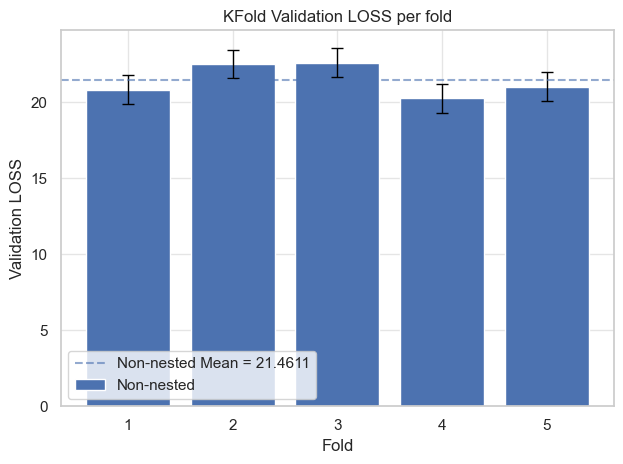

,TR,VL,|TR-VL|
Fold,,,
1,21.141280,20.842604,-0.298676
2,16.025148,22.522790,6.497642
3,19.031175,22.621097,3.589922
4,16.096970,20.270229,4.173260
5,14.994015,21.049016,6.055001
MEAN,17.457717,21.461147,4.003430
STD,2.281145,0.942688,2.414041


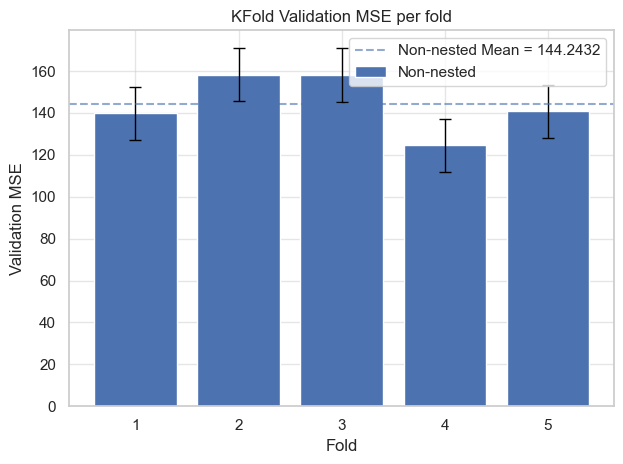

,TR,VL,|TR-VL|
Fold,,,
1,143.388037,139.726688,-3.661349
2,114.302170,158.141333,43.839163
3,123.155569,158.074683,34.919113
4,90.658337,124.547293,33.888956
5,83.895751,140.726208,56.830457
MEAN,111.079973,144.243241,33.163268
STD,21.707320,12.689877,20.168156


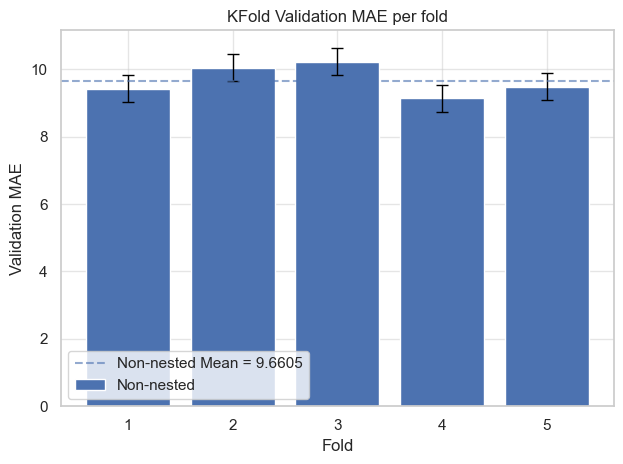

,TR,VL,|TR-VL|
Fold,,,
1,9.498834,9.426967,-0.071867
2,7.236128,10.038516,2.802389
3,8.551088,10.218110,1.667022
4,7.146625,9.143233,1.996608
5,6.599546,9.475454,2.875908
MEAN,7.806444,9.660456,1.854012
STD,1.061688,0.402535,1.068457


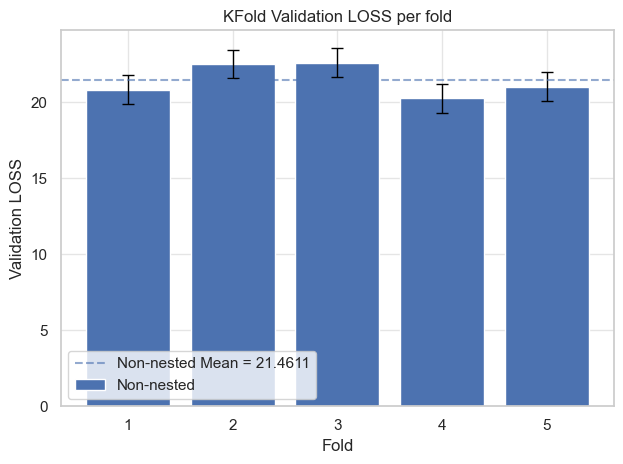

,TR,VL,|TR-VL|
Fold,,,
1,21.141280,20.842604,-0.298676
2,16.025148,22.522790,6.497642
3,19.031175,22.621097,3.589922
4,16.096970,20.270229,4.173260
5,14.994015,21.049016,6.055001
MEAN,17.457717,21.461147,4.003430
STD,2.281145,0.942688,2.414041


In [27]:
importlib.reload(cr)

# LOSS is always present
cr.plot_kfold_metric([(fold_histories,"Non-nested")], LOSS)
display(cr.kfold_summary(fold_histories, use=LOSS))

for metric in the_metrics:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_summary(fold_histories, use=metric))


<h3>Best Hyperparameters</h3>
<hr/>

In [28]:
final_cv_validation_mee = float(np.mean([fold.fold_vl_loss for fold in fold_histories]))
final_cv_training_mee = float(np.mean([fold.fold_tr_loss for fold in fold_histories]))
final_cv_gap = (final_cv_validation_mee - final_cv_training_mee)
final_cv_validation_mee = float(np.mean([fold.fold_vl_loss for fold in fold_histories]))
final_cv_training_mee = float(np.mean([fold.fold_tr_loss for fold in fold_histories]))
final_cv_gap = (final_cv_validation_mee - final_cv_training_mee)

print(f"TRAINING_SEED: {TRAINING_SEED}")
print(f"OPTUNA_SEED: {OPTUNA_SEED}")
print(f"CV_RANDOM_STATE: {CV_RANDOM_STATE}")
print(f"Mean training MEE: {final_cv_training_mee:.4f}")
print(f"Mean CV validation MEE: {final_cv_validation_mee:.4f}")
print(f"Mean training MEE: {final_cv_training_mee:.4f}")
print(f"Mean CV validation MEE: {final_cv_validation_mee:.4f}")
print(f"TR–VL gap: {final_cv_gap:.4f}")
print(f"hidden layers: {final_hidden_layers}")
print(f"activation function: {final_activation}")
for key, value in inner_train_params.items(): print(f"{key}: {value}")

TRAINING_SEED: 20
OPTUNA_SEED: 1
CV_RANDOM_STATE: 42
Mean training MEE: 17.4577
Mean CV validation MEE: 21.4611
Mean training MEE: 17.4577
Mean CV validation MEE: 21.4611
TR–VL gap: 4.0034
hidden layers: [64, 64]
activation function: gelu
epochs: 1000
early_stopping_strategy: EarlyStopping monitoring loss with patience=50, min_delta=0.01
batch_size: 32
scheduler_template: functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', threshold_mode='abs', factor=0.5, patience=10, threshold=0.01)
optimizer_template: functools.partial(<class 'torch.optim.adamw.AdamW'>, lr=0.1089031840661933, weight_decay=5.273579364264809e-06, betas=(0.95, 0.999))
loss_function: MEELoss(reduction='mean') - custom function
additional_metrics: {'mse': (<function mse at 0x11f731850>, <built-in function min>), 'mae': (<function mae at 0x11f731b10>, <built-in function min>), 'loss': (MEELoss(reduction='mean') - custom function, <built-in function min>)}
